# Importing Necessary Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import LabelEncoder

# Implementing KMeans++ algorithm with local search

In [31]:
class KMeans():
    def __init__(self,data,k):
        self.data = data
        self.k = k # Determines the number of clusters.
    #Initialize centroids using the k-means++ algorithm.
    def initialize_centroids(self):
        n_samples, n_features = self.data.shape
        # Choose the first centroid randomly from the data points
        centroids = np.zeros((self.k, n_features))
        centroids[0] = self.data[np.random.choice(n_samples)]
        # Compute the remaining k-1 centroids
        for i in range(1, self.k):
            # Compute the distance from each point to the nearest centroid
            distances = np.min([np.linalg.norm(self.data - centroid, axis=1)**2 for centroid in centroids[:i]], axis=0)
            # Choose the next centroid with a probability proportional to the distance squared
            probabilities = distances / np.sum(distances)
            next_centroid_index = np.random.choice(n_samples, p=probabilities)
            centroids[i] = self.data[next_centroid_index]
        return centroids
    def local_search(self, centroids):
        n_samples, _ = self.data.shape
        k, _ = centroids.shape
        for i in range(k):
            current_centroid = centroids[i]
            best_centroid = current_centroid
            best_distance = np.sum(np.min([np.linalg.norm(self.data - c, axis=1)**2 for c in centroids], axis=0))
            # Try moving the centroid to each point in the dataset
            for j in range(n_samples):
                test_centroid = self.data[j]
                test_centroids = centroids.copy()
                test_centroids[i] = test_centroid
                test_distance = np.sum(np.min([np.linalg.norm(self.data - c, axis=1)**2 for c in test_centroids], axis=0))
                # Update the centroid if the total distance is reduced
                if test_distance < best_distance:
                    best_centroid = test_centroid
                    best_distance = test_distance
            centroids[i] = best_centroid
        return centroids
    def fit(self):
        # Used for show state of algorithm. When convergence became True, clustering will be finished.
        convergence = False 
        centroids = self.initialize_centroids()
        centroids = self.local_search(centroids)
        while not convergence: # Condition for checking state of algorithm
            labels = np.zeros(self.data.shape[0])
            # Calculate distance between any data point and any centroid.
            for i in range(self.data.shape[0]):
                distances = [self.__distance(self.data[i],centroid) for centroid in centroids]
                # Get index of the closest centroid to data point(data[i]).
                label = np.argmin(distances)
                labels[i] = label
            prev_centroids = centroids
            centroids = np.zeros((self.k,self.data.shape[1]))
            # Compute the new centroid (mean of each cluster)
            for i in range(self.k):
                centroids[i] = self.data[labels == i].mean(axis=0)
            # Checking if the algorithm converges or not.
            if np.all(prev_centroids == centroids):
                convergence = True
        return labels,centroids
    # Method for calculating distance between two data points.
    # Euclidean method is used for calculating distance. 
    def __distance(self,x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    # Method for calculating purity
    def _calculate_purity(self, labels, labels_true):
        n_samples = len(labels)
        cluster_labels = np.zeros((self.k, len(set(labels_true))))
        for i in range(n_samples):
            cluster_labels[int(labels[i]), labels_true[i] - 1] += 1
        max_labels = np.max(cluster_labels, axis=1)
        purity = np.sum(max_labels) / n_samples
        return purity

# Implementing KMedians algorithm with local search

In [32]:
class KMedians():
    def __init__(self,data,k):
        self.data = data
        self.k = k # Determines the number of clusters.
    def local_search(self, centroids):
        n_samples, _ = self.data.shape
        k, _ = centroids.shape
        for i in range(k):
            current_centroid = centroids[i]
            best_centroid = current_centroid
            best_distance = np.sum(np.min([np.linalg.norm(self.data - c, axis=1)**2 for c in centroids], axis=0))
            # Try moving the centroid to each point in the dataset
            for j in range(n_samples):
                test_centroid = self.data[j]
                test_centroids = centroids.copy()
                test_centroids[i] = test_centroid
                test_distance = np.sum(np.min([np.linalg.norm(self.data - c, axis=1)**2 for c in test_centroids], axis=0))
                # Update the centroid if the total distance is reduced
                if test_distance < best_distance:
                    best_centroid = test_centroid
                    best_distance = test_distance
            centroids[i] = best_centroid
        return centroids
    def fit(self):
        # Used for show state of algorithm. When convergence became True, clustering will be finished.
        convergence = False 
        # Choosing k point randomly from our data and set them as centroids.
        centroids = self.data[np.random.choice(self.data.shape[0],self.k,replace=False)]
        centroids = self.local_search(centroids)
        while not convergence: # Condition for checking state of algorithm
            labels = np.zeros(self.data.shape[0])
            # Calculate distance between any data point and any centroid.
            for i in range(self.data.shape[0]):
                distances = [self.__distance(self.data[i],centroid) for centroid in centroids]
                # Get index of the closest centroid to data point(data[i]).
                label = np.argmin(distances)
                labels[i] = label
            prev_centroids = centroids
            centroids = np.zeros((self.k,self.data.shape[1]))
            # Compute the new centroid (median of each cluster)
            for i in range(self.k):
                centroids[i] = np.median(self.data[labels == i],axis=0)
            # Checking if the algorithm converges or not.
            if np.all(prev_centroids == centroids):
                convergence = True
        return labels,centroids
    # Method for calculating distance between two data points.
    # Manhattan method is used for calculating distance. 
    def __distance(self,x1, x2):
        return np.sum(np.abs(x1 - x2))
    # Method for calculating purity
    def _calculate_purity(self, labels, labels_true):
        n_samples = len(labels)
        cluster_labels = np.zeros((self.k, len(set(labels_true))))
        for i in range(n_samples):
            cluster_labels[int(labels[i]), labels_true[i] - 1] += 1
        max_labels = np.max(cluster_labels, axis=1)
        purity = np.sum(max_labels) / n_samples
        return purity

In [33]:
def read_data(file_name,sep=""):
    if sep=="":
        df = pd.read_csv(file_name,header=None)
    else:
        df = pd.read_csv(file_name,header=None,sep=sep)

    label_encoder = LabelEncoder()
    df[df.columns[-1]] = label_encoder.fit_transform(df[df.columns[-1]]) + 1
    # Determining the Number of Clusters
    k = len(df[df.columns[-1]].unique())
    true_labels = df[df.columns[-1]].to_numpy()
    data = df[df.columns[:-1]].to_numpy()
    return data,true_labels,k

# Iris

In [34]:
data,true_labels,k = read_data("iris.data")

In [35]:
# K-Means++
# Number of iterations
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_means = KMeans(data,k)
    labels,centroids = k_means.fit()
    # Calculate Purity of clustering
    purity = k_means._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
print(f"Centroids:\n{best_centroids}")
print(f"Purity:\n{best_purity}")

Centroids:
[[6.85       3.07368421 5.74210526 2.07105263]
 [5.006      3.418      1.464      0.244     ]
 [5.9016129  2.7483871  4.39354839 1.43387097]]
Purity:
0.8933333333333333


In [36]:
# K-Medians
#Initialize an instance of the K-Medians algorithm with the desired number of clusters 
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_medians = KMedians(data,k)
    labels,centroids = k_medians.fit()
    # Calculate Purity of clustering
    purity = k_medians._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
print(f"Centroids:\n{best_centroids}")
print(f"Purity:\n{best_purity}")

Centroids:
[[6.5 3.  5.4 1.9]
 [5.7 2.7 4.2 1.3]
 [5.  3.4 1.5 0.2]]
Purity:
0.9


# Glass

In [37]:
data,true_labels,k = read_data("glass.csv")

In [38]:
# K-Means++
# Number of iterations
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_means = KMeans(data,k)
    labels,centroids = k_means.fit()
    # Calculate Purity of clustering
    purity = k_means._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
print(f"Centroids:\n{best_centroids}")
print(f"Purity:\n{best_purity}")

Centroids:
[[1.51724157e+00 1.31417323e+01 3.49165354e+00 1.40039370e+00
  7.27825984e+01 5.92913386e-01 8.33251969e+00 4.45669291e-02
  6.39370079e-02]
 [1.52143086e+00 1.38965714e+01 3.34314286e+00 1.03257143e+00
  7.17914286e+01 1.86285714e-01 9.55085714e+00 7.85714286e-02
  4.80000000e-02]
 [1.51630385e+00 1.46746154e+01 1.65384615e-01 2.12923077e+00
  7.33138462e+01 7.07692308e-02 8.58038462e+00 9.86923077e-01
  1.50000000e-02]
 [1.51318500e+00 1.30100000e+01 0.00000000e+00 3.03000000e+00
  7.05900000e+01 6.21000000e+00 6.94500000e+00 0.00000000e+00
  0.00000000e+00]
 [1.52826714e+00 1.18671429e+01 0.00000000e+00 1.21857143e+00
  7.16728571e+01 2.51428571e-01 1.43157143e+01 4.50000000e-01
  1.37142857e-01]
 [1.52013529e+00 1.31335294e+01 5.72941176e-01 1.48647059e+00
  7.30682353e+01 5.01764706e-01 1.10052941e+01 1.41176471e-02
  6.17647059e-02]]
Purity:
0.5841121495327103


In [39]:
# K-Medians
#Initialize an instance of the K-Medians algorithm with the desired number of clusters 
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_medians = KMedians(data,k)
    labels,centroids = k_medians.fit()
    # Calculate Purity of clustering
    purity = k_medians._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
print(f"Centroids:\n{best_centroids}")
print(f"Purity:\n{best_purity}")

Centroids:
[[ 1.5164  14.7      0.       2.02    73.23     0.       8.62     0.76
   0.     ]
 [ 1.51321 13.02     0.       3.04    70.48     6.21     6.93     0.
   0.     ]
 [ 1.52007 13.325    0.       1.56    72.945    0.355   11.245    0.
   0.     ]
 [ 1.51749 13.095    3.52     1.35    72.85     0.59     8.405    0.
   0.     ]
 [ 1.52152 13.81     3.65     0.89    71.87     0.11     9.57     0.
   0.     ]
 [ 1.52739 11.45     0.       1.      72.02     0.12    14.4      0.
   0.1    ]]
Purity:
0.5747663551401869


# R15

In [40]:
data,true_labels,k = read_data("R15.data","\t")

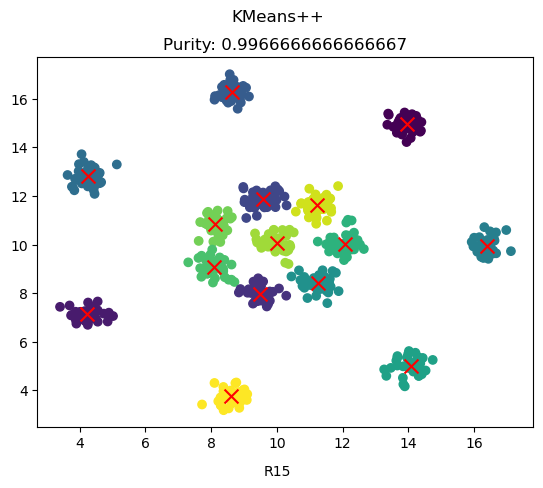

In [41]:
# K-Means++
# Number of iterations
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_means = KMeans(data,k)
    labels,centroids = k_means.fit()
    # Calculate Purity of clustering
    purity = k_means._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
# Plot the results. 
plt.suptitle("KMeans++")
plt.title(f"Purity: {best_purity}")
plt.figtext(0.5, 0.01, "R15", ha="center")
# Plot data points.(c(colors) option is used to show clusters.) 
plt.scatter(data[:, 0], data[:, 1], c=best_labels, cmap='viridis')
# Plot centroids.
plt.scatter(best_centroids[:, 0], best_centroids[:, 1], marker='x', color='red', s=100)
plt.show()

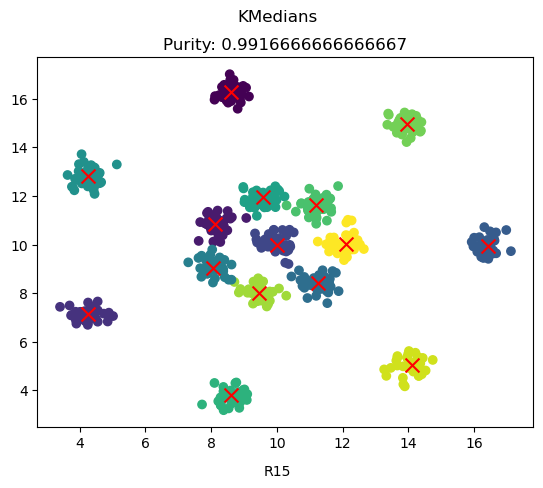

In [42]:
# K-Medians
#Initialize an instance of the K-Medians algorithm with the desired number of clusters 
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_medians = KMedians(data,k)
    labels,centroids = k_medians.fit()
    # Calculate Purity of clustering
    purity = k_medians._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
# Plot the results. 
plt.suptitle("KMedians")
plt.title(f"Purity: {best_purity}")
plt.figtext(0.5, 0.01, "R15", ha="center")
# Plot data points.(c(colors) option is used to show clusters.) 
plt.scatter(data[:, 0], data[:, 1], c=best_labels, cmap='viridis')
# Plot centroids.
plt.scatter(best_centroids[:, 0], best_centroids[:, 1], marker='x', color='red', s=100)
plt.show()

# Aggregation

In [43]:
data,true_labels,k = read_data("Aggregation.data","\t")

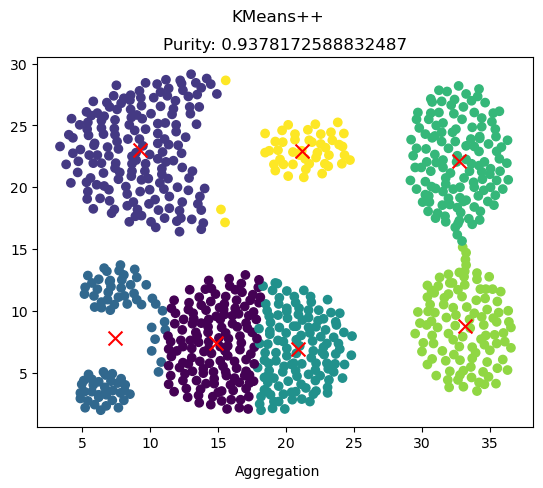

In [44]:
# K-Means++
# Number of iterations
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_means = KMeans(data,k)
    labels,centroids = k_means.fit()
    # Calculate Purity of clustering
    purity = k_means._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
# Plot the results. 
plt.suptitle("KMeans++")
plt.title(f"Purity: {best_purity}")
plt.figtext(0.5, 0.01, "Aggregation", ha="center")
# Plot data points.(c(colors) option is used to show clusters.) 
plt.scatter(data[:, 0], data[:, 1], c=best_labels, cmap='viridis')
# Plot centroids.
plt.scatter(best_centroids[:, 0], best_centroids[:, 1], marker='x', color='red', s=100)
plt.show()

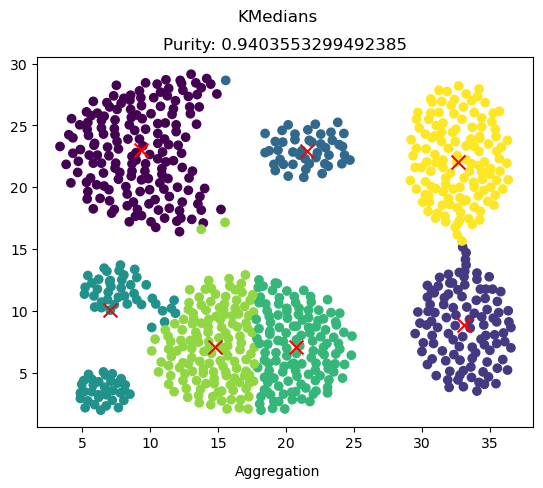

In [45]:
# K-Medians
#Initialize an instance of the K-Medians algorithm with the desired number of clusters 
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_medians = KMedians(data,k)
    labels,centroids = k_medians.fit()
    # Calculate Purity of clustering
    purity = k_medians._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
# Plot the results. 
plt.suptitle("KMedians")
plt.title(f"Purity: {best_purity}")
plt.figtext(0.5, 0.01, "Aggregation", ha="center")
# Plot data points.(c(colors) option is used to show clusters.) 
plt.scatter(data[:, 0], data[:, 1], c=best_labels, cmap='viridis')
# Plot centroids.
plt.scatter(best_centroids[:, 0], best_centroids[:, 1], marker='x', color='red', s=100)
plt.show()

# D31

In [46]:
data,true_labels,k = read_data("D31.data","\t")

In [47]:
# K-Means++
# Number of iterations
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_means = KMeans(data,k)
    labels,centroids = k_means.fit()
    # Calculate Purity of clustering
    purity = k_means._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
print(f"Centroids:\n{best_centroids}")
print(f"Purity:\n{best_purity}")

Centroids:
[[25.226476   27.836792  ]
 [ 8.63955253 15.23474444]
 [16.309468   14.806073  ]
 [13.90715729 18.69180417]
 [25.56785248  6.06014059]
 [21.31863663 27.42099208]
 [15.58483469  9.27656837]
 [14.06262727 26.7166697 ]
 [11.6917703  14.42824653]
 [15.40105545 21.93952277]
 [22.70667778 11.85706667]
 [24.80992323 24.34955152]
 [ 5.407537   27.575742  ]
 [26.77086634 22.02195842]
 [27.24742178 17.51628119]
 [ 5.092299   10.18811   ]
 [12.149964   21.394745  ]
 [ 5.34684948 20.25533093]
 [11.38362745  8.32036569]
 [10.257938   24.376948  ]
 [ 8.71504118 21.23696275]
 [20.325291   19.631174  ]
 [ 8.33582143 10.30574796]
 [17.919376   25.776084  ]
 [22.896806   16.202219  ]
 [26.097785   14.686634  ]
 [22.10633846  5.62033654]
 [23.27342887  8.60741959]
 [26.88637755 10.29434184]
 [17.53417379 11.60580097]
 [ 5.83268932 16.94856699]]
Purity:
0.9780645161290322


In [48]:
# K-Medians
#Initialize an instance of the K-Medians algorithm with the desired number of clusters 
iterations = 10
best_purity = 0
for i in range(iterations):
    #Initialize an instance of the KMeans algorithm with the desired number of clusters 
    k_medians = KMedians(data,k)
    labels,centroids = k_medians.fit()
    # Calculate Purity of clustering
    purity = k_medians._calculate_purity(labels, true_labels)
    if purity > best_purity:
        best_purity = purity
        best_labels = labels
        best_centroids = centroids
print(f"Centroids:\n{best_centroids}")
print(f"Purity:\n{best_purity}")

Centroids:
[[14.0919  26.7672 ]
 [15.6421   9.3102 ]
 [20.3502  19.5659 ]
 [15.3799  21.8751 ]
 [26.13585 14.63815]
 [ 8.6938  21.3484 ]
 [25.4838   6.0603 ]
 [18.041   25.7368 ]
 [22.963   16.0814 ]
 [11.4699   8.289  ]
 [11.6562  14.4231 ]
 [17.5488  11.6539 ]
 [ 5.35305 20.14205]
 [26.89025 10.31415]
 [27.1881  17.4913 ]
 [22.16375  5.6256 ]
 [13.8849  18.7816 ]
 [10.2762  24.3131 ]
 [ 8.7306  15.2143 ]
 [23.27695  8.5167 ]
 [22.6778  11.85515]
 [16.28495 14.775  ]
 [ 5.01035 10.21065]
 [26.7212  22.0039 ]
 [21.22305 27.43765]
 [24.7248  24.4189 ]
 [ 8.2913  10.3268 ]
 [25.2262  27.8045 ]
 [12.1323  21.422  ]
 [ 5.414   27.56185]
 [ 5.8901  16.8933 ]]
Purity:
0.9741935483870968
